# Evaluating Signal Independence Between GCaMP6f and jRGECO1a

## Overview

After defining the range-based signal representation from spectrometer output, the next step was to determine whether GCaMP6f[1] and jRGECO1a[2] could be interpreted independently under actual recording conditions. This comparison was essential because dual-color measurement is only meaningful when fluorescence changes observed in the green and red ranges can be attributed to the intended sensor with sufficient confidence.

The analysis therefore focused on two representative measurement ranges, 517 nm and 590 nm, corresponding to the green and red signal regions used throughout the project. Using these predefined wavelength ranges, the following comparisons tested whether each sensor remained confined to its expected measurement region at baseline and during event-related responses.
  
[1] Zhang et al,. Nature (https://www.nature.com/articles/s41586-023-05828-9)  
[2] Dana et al,. eLife (https://elifesciences.org/articles/12727)

## Baseline Spectral Separation at Rest

Before evaluating event-related responses, the baseline spectral profiles of GCaMP6f and jRGECO1a were examined under 473 nm and 561 nm excitation.  
This comparison was used to determine whether each sensor remained largely confined to its expected wavelength range under resting conditions or whether detectable signal was also present in the opposite measurement region.

The baseline comparison provided the first reference point for evaluating signal independence, because any overlap observed at rest would already complicate later interpretation under event-related recording conditions. This resting-state comparison established the minimum expectation for sensor independence before activity-related responses were examined.

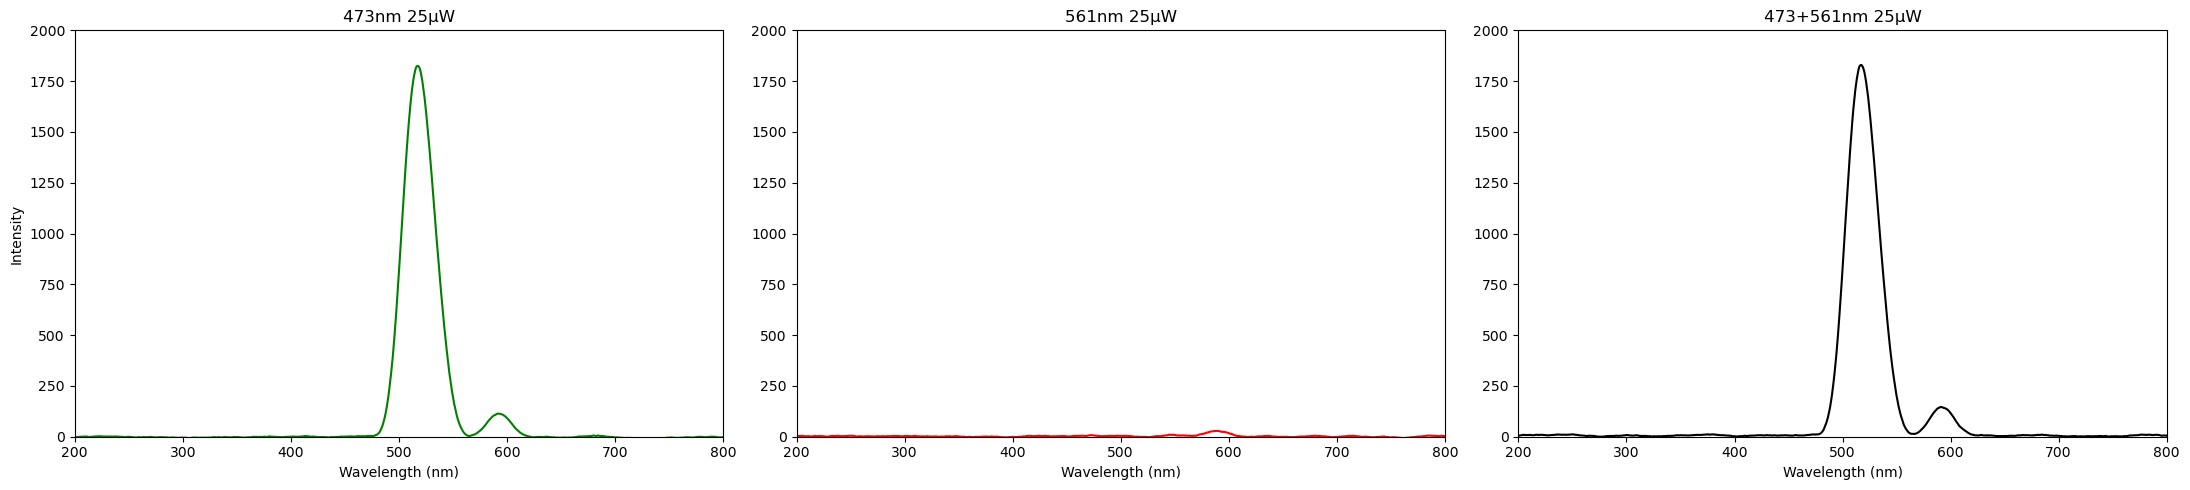

In [1]:
# Load baseline spectra from the single-sensor control condition
# to inspect whether each sensor remains confined to its expected range at rest

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
BASELINE_DIR = PROJECT_ROOT / "data" / "baseline"
GCAMP_BASELINE_DIR = BASELINE_DIR / "GCaMP"

g_file = GCAMP_BASELINE_DIR / "NoRef_Flna14_g25uw.txt"
r_file = GCAMP_BASELINE_DIR / "NoRef_Flna14_r25uw.txt"
gr_file = GCAMP_BASELINE_DIR / "NoRef_Flna14_gr25uw.txt"

g = np.loadtxt(g_file)
r = np.loadtxt(r_file)
gr = np.loadtxt(gr_file)

g_x, g_y = g[:, 0], g[:, 1]
r_x, r_y = r[:, 0], r[:, 1]
gr_x, gr_y = gr[:, 0], gr[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# Baseline spectrum under 473 nm excitation
axes[0].plot(g_x, g_y, color='green')
axes[0].set_title("473nm 25µW")
axes[0].set_xlim(200, 800)
axes[0].set_ylim(0, 2000)
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Intensity")

# Baseline spectrum under 561 nm excitation
axes[1].plot(r_x, r_y, color='red')
axes[1].set_title("561nm 25µW")
axes[1].set_xlim(200, 800)
axes[1].set_ylim(0, 2000)
axes[1].set_xlabel("Wavelength (nm)")

# Baseline spectrum under combined 473 nm and 561 nm excitation
axes[2].plot(gr_x, gr_y, color='black')
axes[2].set_title("473+561nm 25µW")
axes[2].set_xlim(200, 800)
axes[2].set_ylim(0, 2000)
axes[2].set_xlabel("Wavelength (nm)")

plt.tight_layout()
plt.show()


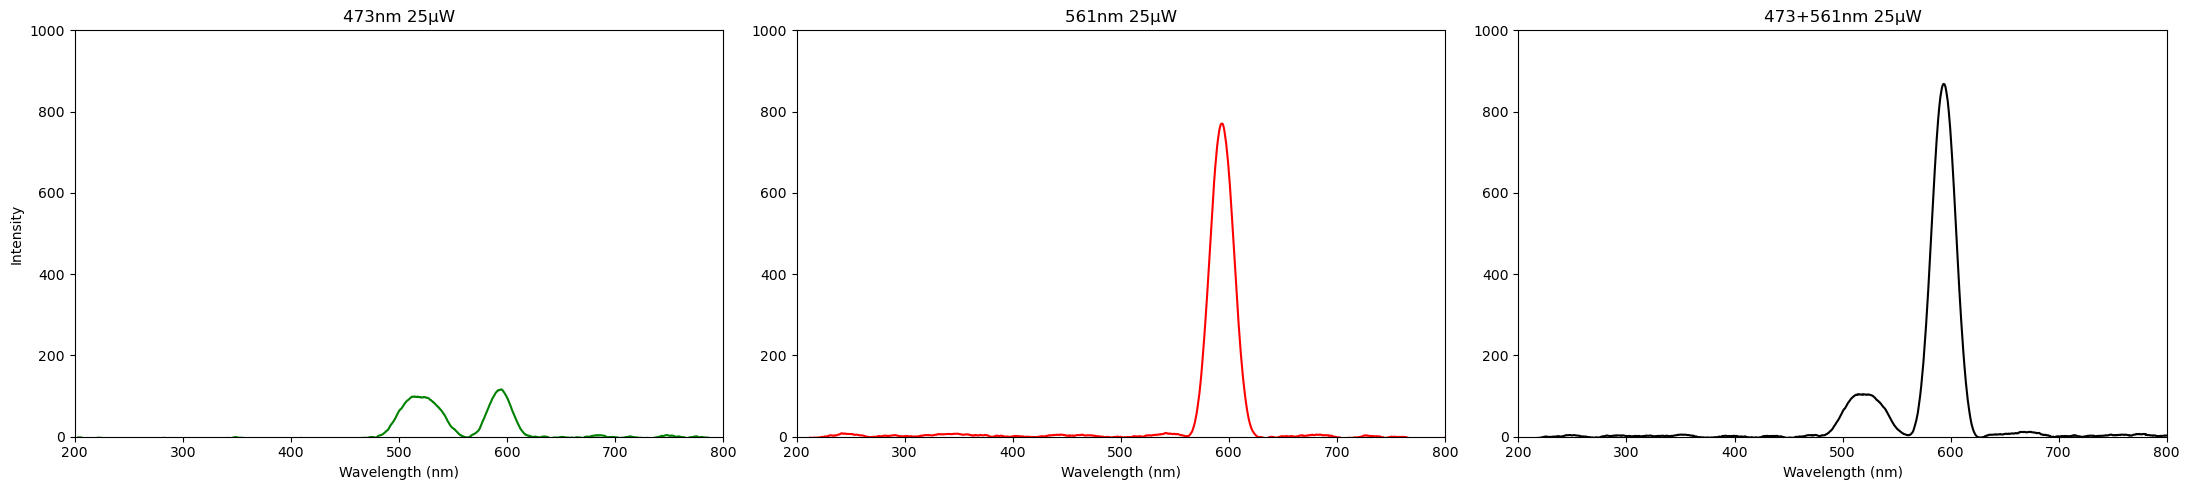

In [2]:
# Load baseline spectra from the single-sensor control condition
# to inspect whether each sensor remains confined to its expected range at rest

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
BASELINE_DIR = PROJECT_ROOT / "data" / "baseline"
JRGECO_BASELINE_DIR = BASELINE_DIR / "jRGECO"

g_file = JRGECO_BASELINE_DIR / "NoRef_Flna18_g25uw.txt"
r_file = JRGECO_BASELINE_DIR / "NoRef_Flna18_r25uw.txt"
gr_file = JRGECO_BASELINE_DIR / "NoRef_Flna18_gr25uw.txt"

g = np.loadtxt(g_file)
r = np.loadtxt(r_file)
gr = np.loadtxt(gr_file)

g_x, g_y = g[:, 0], g[:, 1]
r_x, r_y = r[:, 0], r[:, 1]
gr_x, gr_y = gr[:, 0], gr[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# Baseline spectrum under 473 nm excitation
axes[0].plot(g_x, g_y, color='green')
axes[0].set_title("473nm 25µW")
axes[0].set_xlim(200, 800)
axes[0].set_ylim(0, 1000)
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Intensity")

# Baseline spectrum under 561 nm excitation
axes[1].plot(r_x, r_y, color='red')
axes[1].set_title("561nm 25µW")
axes[1].set_xlim(200, 800)
axes[1].set_ylim(0, 1000)
axes[1].set_xlabel("Wavelength (nm)")

# Baseline spectrum under combined 473 nm and 561 nm excitation
axes[2].plot(gr_x, gr_y, color='black')
axes[2].set_title("473+561nm 25µW")
axes[2].set_xlim(200, 800)
axes[2].set_ylim(0, 1000)
axes[2].set_xlabel("Wavelength (nm)")

plt.tight_layout()
plt.show()


## Event-Related Response Comparison Under Single-Sensor Conditions

The next step was to compare event-related responses from each sensor under single-sensor recording conditions. The key question was whether excitation of each sensor produced responses that remained confined to its expected measurement range, or whether event-related fluorescence also appeared in the opposite channel.

This comparison was important because dual-color interpretation depends not only on baseline spectral separation, but also on whether activity-related signal changes remain sensor-specific during behaviorally relevant events. This step was essential because contamination that appears negligible at rest can become more consequential during event-driven signal changes.

Loaded: C:\Users\admin\project\data\sample\GCaMP\Flna11_473nm_stimuli_python.mat
Loaded: C:\Users\admin\project\data\sample\GCaMP\Flna11_561nm_stimuli_python.mat
Both files loaded!

Unified Y-axis range → [-37.958, 661.184]


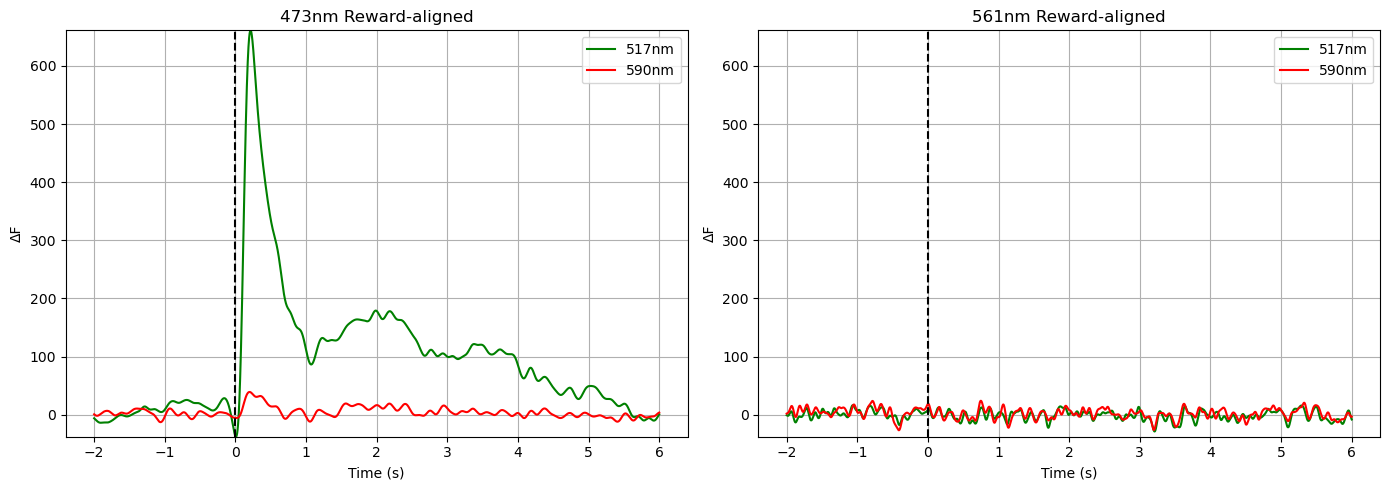

In [9]:
# Load single-sensor sample datasets for reward-aligned response comparison
# and compute baseline-corrected signal segments in the green and red ranges

import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SAMPLE_DIR = PROJECT_ROOT / "data" / "sample" / "GCaMP"

FILE_473 = SAMPLE_DIR / "Flna11_473nm_stimuli_python.mat"
FILE_561 = SAMPLE_DIR / "Flna11_561nm_stimuli_python.mat"

def load_stimuli_file(mat_path):
    if not mat_path.exists():
        raise FileNotFoundError(f"Sample dataset not found: {mat_path}")

    data = loadmat(mat_path)

    photo1 = data['photo1'].flatten()
    photo2 = data['photo2'].flatten()
    sol1times = data['sol1times'].flatten()
    cue1times = data['cue1times'].flatten()
    downsamplingrate = int(data['downsamplingrate'][0][0])

    return photo1, photo2, sol1times, cue1times, downsamplingrate

photo1_A, photo2_A, sol1_A, cue1_A, rate_A = load_stimuli_file(FILE_473)
photo1_B, photo2_B, sol1_B, cue1_B, rate_B = load_stimuli_file(FILE_561)

# Compute reward-aligned signal segments for single-sensor response comparison
def compute_reward_aligned(photo1, photo2, sol1times, rate):
    pre, post = 2, 6
    win_size = int((pre + post) * rate)

    photometry1_sol1 = []
    photometry2_sol1 = []

    for t in sol1times:
        idx = int(t * rate)

        start = idx - int(pre * rate)
        end = idx + int(post * rate)

        if start >= 0 and end < len(photo1):

            base_start = idx - int(3 * rate)
            base_end = idx - int(2 * rate)

            baseline1 = np.mean(photo1[base_start:base_end])
            baseline2 = np.mean(photo2[base_start:base_end])

            segment1 = photo1[start:end] - baseline1
            segment2 = photo2[start:end] - baseline2

            photometry1_sol1.append(segment1)
            photometry2_sol1.append(segment2)

    return (
        np.array(photometry1_sol1),
        np.array(photometry2_sol1),
        np.linspace(-pre, post, np.array(photometry1_sol1).shape[1])
    )


p1_A, p2_A, t_A = compute_reward_aligned(photo1_A, photo2_A, sol1_A, rate_A)
p1_B, p2_B, t_B = compute_reward_aligned(photo1_B, photo2_B, sol1_B, rate_B)

ymin_A = np.min([p1_A.mean(axis=0), p2_A.mean(axis=0)])
ymax_A = np.max([p1_A.mean(axis=0), p2_A.mean(axis=0)])

ymin_B = np.min([p1_B.mean(axis=0), p2_B.mean(axis=0)])
ymax_B = np.max([p1_B.mean(axis=0), p2_B.mean(axis=0)])

ymin = min(ymin_A, ymin_B)
ymax = max(ymax_A, ymax_B)

print(f"Unified Y-axis range → [{ymin:.3f}, {ymax:.3f}]")

plt.figure(figsize=(14, 5))

# ---- LEFT: 473nm ----
plt.subplot(1, 2, 1)
plt.plot(t_A, p1_A.mean(axis=0), color='green', label='517nm')
plt.plot(t_A, p2_A.mean(axis=0), color='red', label='590nm')
plt.axvline(0, linestyle='--', color='black')
plt.title('473nm Reward-aligned')
plt.xlabel('Time (s)')
plt.ylabel('ΔF')
plt.legend()
plt.grid()
plt.ylim(ymin, ymax)

# ---- RIGHT: 561nm ----
plt.subplot(1, 2, 2)
plt.plot(t_B, p1_B.mean(axis=0), color='green', label='517nm')
plt.plot(t_B, p2_B.mean(axis=0), color='red', label='590nm')
plt.axvline(0, linestyle='--', color='black')
plt.title('561nm Reward-aligned')
plt.xlabel('Time (s)')
plt.ylabel('ΔF')
plt.legend()
plt.grid()
plt.ylim(ymin, ymax)

plt.tight_layout()
plt.show()

Loaded: C:\Users\admin\project\data\sample\jRGECO\Flna33_473nm_stimuli_python.mat
Loaded: C:\Users\admin\project\data\sample\jRGECO\Flna33_561nm_stimuli_python.mat
Both files loaded!

Unified Y-axis range → [-88.233, 970.132]


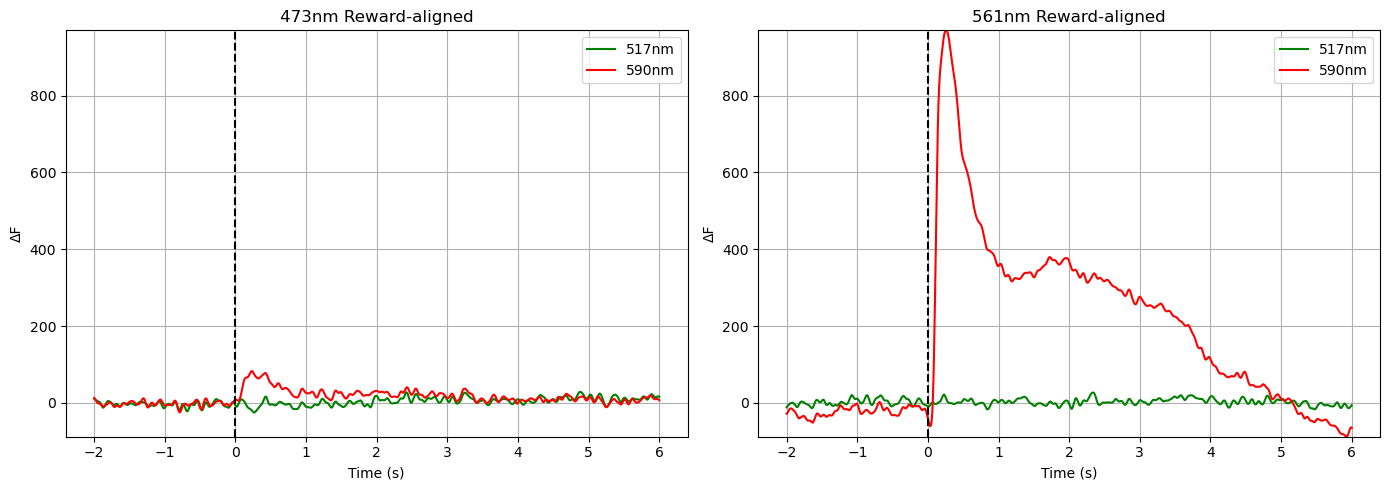

In [10]:
# Load single-sensor sample datasets for reward-aligned response comparison
# and compute baseline-corrected signal segments in the green and red ranges

import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SAMPLE_DIR = PROJECT_ROOT / "data" / "sample" / "jRGECO"

FILE_473 = SAMPLE_DIR / "Flna33_473nm_stimuli_python.mat"
FILE_561 = SAMPLE_DIR / "Flna33_561nm_stimuli_python.mat"

def load_stimuli_file(mat_path):
    if not mat_path.exists():
        raise FileNotFoundError(f"Sample dataset not found: {mat_path}")

    data = loadmat(mat_path)


    photo1 = data['photo1'].flatten()
    photo2 = data['photo2'].flatten()
    sol1times = data['sol1times'].flatten()
    cue1times = data['cue1times'].flatten()
    downsamplingrate = int(data['downsamplingrate'][0][0])

    return photo1, photo2, sol1times, cue1times, downsamplingrate

photo1_A, photo2_A, sol1_A, cue1_A, rate_A = load_stimuli_file(FILE_473)
photo1_B, photo2_B, sol1_B, cue1_B, rate_B = load_stimuli_file(FILE_561)

# Compute reward-aligned signal segments for single-sensor response comparison
def compute_reward_aligned(photo1, photo2, sol1times, rate):
    pre, post = 2, 6
    win_size = int((pre + post) * rate)

    photometry1_sol1 = []
    photometry2_sol1 = []

    for t in sol1times:
        idx = int(t * rate)

        start = idx - int(pre * rate)
        end = idx + int(post * rate)

        if start >= 0 and end < len(photo1):

            base_start = idx - int(3 * rate)
            base_end = idx - int(2 * rate)

            baseline1 = np.mean(photo1[base_start:base_end])
            baseline2 = np.mean(photo2[base_start:base_end])

            segment1 = photo1[start:end] - baseline1
            segment2 = photo2[start:end] - baseline2

            photometry1_sol1.append(segment1)
            photometry2_sol1.append(segment2)

    return (
        np.array(photometry1_sol1),
        np.array(photometry2_sol1),
        np.linspace(-pre, post, np.array(photometry1_sol1).shape[1])
    )

p1_A, p2_A, t_A = compute_reward_aligned(photo1_A, photo2_A, sol1_A, rate_A)
p1_B, p2_B, t_B = compute_reward_aligned(photo1_B, photo2_B, sol1_B, rate_B)


ymin_A = np.min([p1_A.mean(axis=0), p2_A.mean(axis=0)])
ymax_A = np.max([p1_A.mean(axis=0), p2_A.mean(axis=0)])

ymin_B = np.min([p1_B.mean(axis=0), p2_B.mean(axis=0)])
ymax_B = np.max([p1_B.mean(axis=0), p2_B.mean(axis=0)])

ymin = min(ymin_A, ymin_B)
ymax = max(ymax_A, ymax_B)

print(f"Unified Y-axis range → [{ymin:.3f}, {ymax:.3f}]")

plt.figure(figsize=(14, 5))

# ---- LEFT: 473nm ----
plt.subplot(1, 2, 1)
plt.plot(t_A, p1_A.mean(axis=0), color='green', label='517nm')
plt.plot(t_A, p2_A.mean(axis=0), color='red', label='590nm')
plt.axvline(0, linestyle='--', color='black')
plt.title('473nm Reward-aligned')
plt.xlabel('Time (s)')
plt.ylabel('ΔF')
plt.legend()
plt.grid()
plt.ylim(ymin, ymax)

# ---- RIGHT: 561nm ----
plt.subplot(1, 2, 2)
plt.plot(t_B, p1_B.mean(axis=0), color='green', label='517nm')
plt.plot(t_B, p2_B.mean(axis=0), color='red', label='590nm')
plt.axvline(0, linestyle='--', color='black')
plt.title('561nm Reward-aligned')
plt.xlabel('Time (s)')
plt.ylabel('ΔF')
plt.legend()
plt.grid()
plt.ylim(ymin, ymax)

plt.tight_layout()
plt.show()

## Standardized Comparison of Sensor Independence

To compare sensor-specific responses on a common scale, the event-aligned fluorescence traces were transformed into z-scores. This normalization reduced the influence of baseline brightness, expression level, and absolute signal amplitude, allowing responses in the green and red measurement ranges to be compared more directly.

The standardized comparison was then used to determine whether GCaMP6f and jRGECO1a remained confined to their expected measurement ranges, or whether meaningful responses could also be detected in the opposite channel after normalization.

Loaded: C:\Users\admin\project\data\sample\GCaMP\Flna11_473nm_stimuli_python.mat
Loaded: C:\Users\admin\project\data\sample\GCaMP\Flna11_561nm_stimuli_python.mat
Both files loaded!

Valid trials (473nm): 40, (561nm): 40
Unified Y-axis range (z-score) → [-0.717, 13.582]


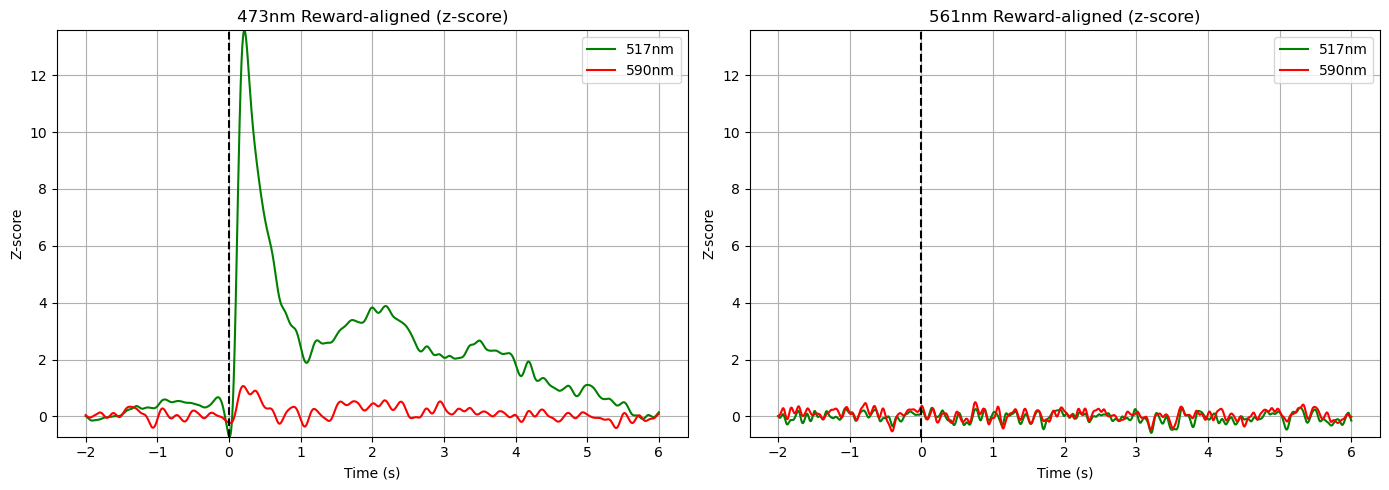

In [12]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SAMPLE_DIR = PROJECT_ROOT / "data" / "sample" / "GCaMP"

FILE_473 = SAMPLE_DIR / "Flna11_473nm_stimuli_python.mat"
FILE_561 = SAMPLE_DIR / "Flna11_561nm_stimuli_python.mat"

def load_stimuli_file(mat_path):
    if not mat_path.exists():
        raise FileNotFoundError(f"Sample dataset not found: {mat_path}")

    data = loadmat(mat_path)

    photo1 = data['photo1'].flatten()
    photo2 = data['photo2'].flatten()
    sol1times = data['sol1times'].flatten()
    cue1times = data['cue1times'].flatten()
    downsamplingrate = int(data['downsamplingrate'][0][0])

    return photo1, photo2, sol1times, cue1times, downsamplingrate

photo1_A, photo2_A, sol1_A, cue1_A, rate_A = load_stimuli_file(FILE_473)
photo1_B, photo2_B, sol1_B, cue1_B, rate_B = load_stimuli_file(FILE_561)

print("Validation datasets loaded successfully")

# Compute reward-aligned z-score traces for standardized comparison
def compute_reward_aligned_zscore(photo1, photo2, sol1times, rate):
    pre, post = 2, 6  # -2 ~ +6 s

    zphoto1_trials = []
    zphoto2_trials = []

    for t in sol1times:
        idx = int(t * rate)

        start = idx - int(pre * rate)
        end   = idx + int(post * rate)

        if start >= 0 and end < len(photo1):

            # basUse the -3 s to -2 s interval as the baseline window for z-score normalization
            base_start = idx - int(3 * rate)
            base_end   = idx - int(2 * rate)

            base1 = photo1[base_start:base_end]
            base2 = photo2[base_start:base_end]

            mean1 = np.mean(base1)
            std1  = np.std(base1)
            mean2 = np.mean(base2)
            std2  = np.std(base2)

            if std1 < 1e-6 or std2 < 1e-6:
                continue

            seg1 = photo1[start:end]
            seg2 = photo2[start:end]

            zseg1 = (seg1 - mean1) / std1
            zseg2 = (seg2 - mean2) / std2

            zphoto1_trials.append(zseg1)
            zphoto2_trials.append(zseg2)

    zphoto1_trials = np.array(zphoto1_trials)
    zphoto2_trials = np.array(zphoto2_trials)

    time_vec = np.linspace(-pre, post, zphoto1_trials.shape[1])

    return zphoto1_trials, zphoto2_trials, time_vec

z1_A, z2_A, t_A = compute_reward_aligned_zscore(photo1_A, photo2_A, sol1_A, rate_A)
z1_B, z2_B, t_B = compute_reward_aligned_zscore(photo1_B, photo2_B, sol1_B, rate_B)

print(f"Valid trials (473nm): {z1_A.shape[0]}, (561nm): {z1_B.shape[0]}")


ymin_A = np.min([z1_A.mean(axis=0), z2_A.mean(axis=0)])
ymax_A = np.max([z1_A.mean(axis=0), z2_A.mean(axis=0)])

ymin_B = np.min([z1_B.mean(axis=0), z2_B.mean(axis=0)])
ymax_B = np.max([z1_B.mean(axis=0), z2_B.mean(axis=0)])

ymin = min(ymin_A, ymin_B)
ymax = max(ymax_A, ymax_B)

print(f"Unified Y-axis range (z-score) → [{ymin:.3f}, {ymax:.3f}]")

plt.figure(figsize=(14, 5))

# ---- LEFT: 473nm ----
plt.subplot(1, 2, 1)
plt.plot(t_A, z1_A.mean(axis=0), color='green', label='517nm')
plt.plot(t_A, z2_A.mean(axis=0), color='red',   label='590nm')
plt.axvline(0, linestyle='--', color='black')
plt.title('473nm Reward-aligned (z-score)')
plt.xlabel('Time (s)')
plt.ylabel('Z-score')
plt.legend()
plt.grid()
plt.ylim(ymin, ymax)

# ---- RIGHT: 561nm ----
plt.subplot(1, 2, 2)
plt.plot(t_B, z1_B.mean(axis=0), color='green', label='517nm')
plt.plot(t_B, z2_B.mean(axis=0), color='red',   label='590nm')
plt.axvline(0, linestyle='--', color='black')
plt.title('561nm Reward-aligned (z-score)')
plt.xlabel('Time (s)')
plt.ylabel('Z-score')
plt.legend()
plt.grid()
plt.ylim(ymin, ymax)

plt.tight_layout()
plt.show()


### GCaMP6f Extension Into the Red Measurement Range

The standardized comparison revealed a clear asymmetry: under 473 nm excitation, GCaMP6f produced not only a response in the 517 nm range but also a measurable response in the 590 nm range. Although the red-range signal was smaller than the primary green response, its presence was sufficient to create ambiguity because 590 nm was also the principal measurement range used to quantify the red sensor.

The bar-based summary below was used to quantify the magnitude of this cross-range response more clearly.


Select 473nm file
Loaded: C:\Users\admin\project\data\sample\GCaMP\Flna11_473nm_stimuli_python.mat

Select 561nm file
Loaded: C:\Users\admin\project\data\sample\GCaMP\Flna11_561nm_stimuli_python.mat


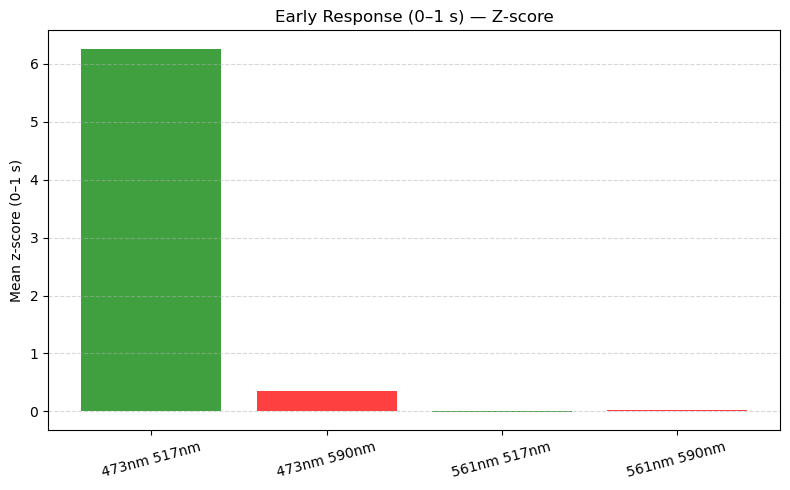

In [17]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SAMPLE_DIR = PROJECT_ROOT / "data" / "sample" / "GCaMP"

FILE_473 = SAMPLE_DIR / "Flna11_473nm_stimuli_python.mat"
FILE_561 = SAMPLE_DIR / "Flna11_561nm_stimuli_python.mat"

def load_stimuli_file(mat_path):
    if not mat_path.exists():
        raise FileNotFoundError(f"Sample dataset not found: {mat_path}")

    data = loadmat(mat_path)

    photo1 = data['photo1'].flatten()
    photo2 = data['photo2'].flatten()
    sol1times = data['sol1times'].flatten()
    downsamplingrate = int(data['downsamplingrate'][0][0])

    return photo1, photo2, sol1times, downsamplingrate

# Compute reward-aligned z-score traces for standardized comparison
def compute_reward_aligned_zscore(photo1, photo2, sol1times, rate):
    pre, post = 2, 6
    zphoto1 = []
    zphoto2 = []

    for t in sol1times:
        idx = int(t * rate)
        start = idx - int(pre * rate)
        end   = idx + int(post * rate)

        if start < 0 or end >= len(photo1):
            continue

        base_start = idx - int(3 * rate)
        base_end   = idx - int(2 * rate)

        if base_start < 0:
            continue

        b1 = photo1[base_start:base_end]
        b2 = photo2[base_start:base_end]

        m1, s1 = np.mean(b1), np.std(b1)
        m2, s2 = np.mean(b2), np.std(b2)

        if s1 < 1e-6 or s2 < 1e-6:
            continue

        seg1 = photo1[start:end]
        seg2 = photo2[start:end]

        zseg1 = (seg1 - m1) / s1
        zseg2 = (seg2 - m2) / s2

        zphoto1.append(zseg1)
        zphoto2.append(zseg2)

    zphoto1 = np.array(zphoto1)
    zphoto2 = np.array(zphoto2)

    time_vec = np.linspace(-pre, post, zphoto1.shape[1])
    return zphoto1, zphoto2, time_vec

def compute_early_response(z1, z2, time_vec):
    idx0 = np.argmin(np.abs(time_vec - 0))
    idx1 = np.argmin(np.abs(time_vec - 1))

    r1 = z1[:, idx0:idx1].mean(axis=1)
    r2 = z2[:, idx0:idx1].mean(axis=1)

    return r1.mean(), r2.mean()

if __name__ == "__main__":

    print("\nSelect 473nm file")
    p1_A, p2_A, sol1_A, rate_A = load_stimuli_file(FILE_473)

    print("\nSelect 561nm file")
    p1_B, p2_B, sol1_B, rate_B = load_stimuli_file(FILE_561)

    # Compute reward-aligned z-score traces
    z1_A, z2_A, t_A = compute_reward_aligned_zscore(p1_A, p2_A, sol1_A, rate_A)
    z1_B, z2_B, t_B = compute_reward_aligned_zscore(p1_B, p2_B, sol1_B, rate_B)

    # Early response
    r1_A, r2_A = compute_early_response(z1_A, z2_A, t_A)
    r1_B, r2_B = compute_early_response(z1_B, z2_B, t_B)

    labels = ['473nm 517nm', '473nm 590nm', '561nm 517nm', '561nm 590nm']
    values = [r1_A, r2_A, r1_B, r2_B]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, values, color=['green', 'red', 'green', 'red'], alpha=0.75)
    plt.ylabel("Mean z-score (0–1 s)")
    plt.title("Early Response (0–1 s) — Z-score")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=15)

    plt.tight_layout()
    plt.show()


Loaded: C:\Users\admin\project\data\sample\jRGECO\Flna33_473nm_stimuli_python.mat
Loaded: C:\Users\admin\project\data\sample\jRGECO\Flna33_561nm_stimuli_python.mat
Both files loaded!

Valid trials (473nm): 50, (561nm): 50
Unified Y-axis range (z-score) → [-1.025, 13.342]


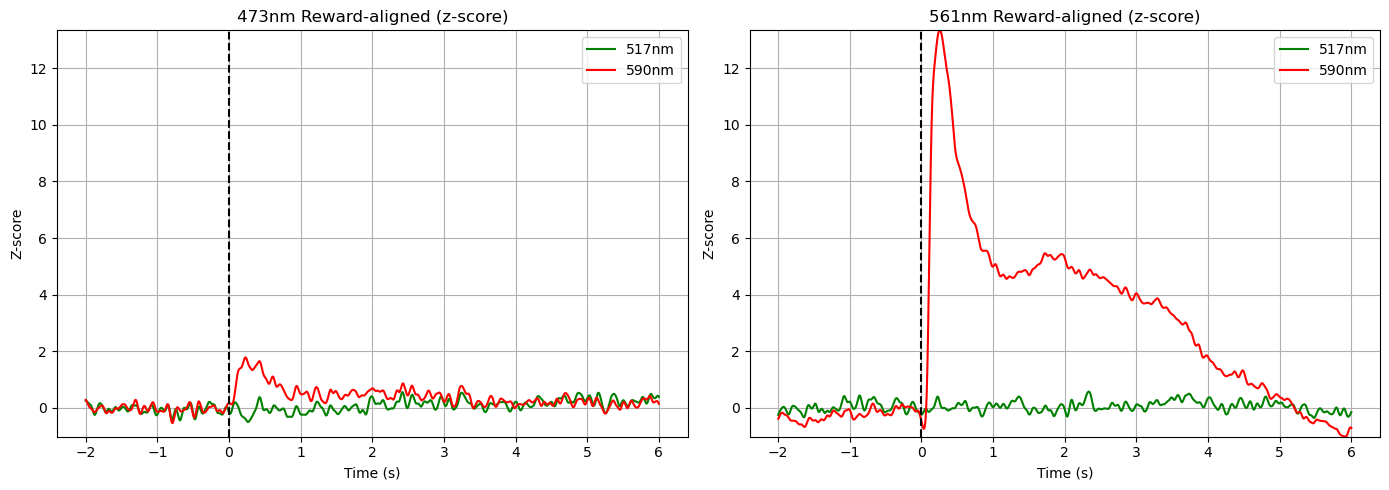

In [14]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SAMPLE_DIR = PROJECT_ROOT / "data" / "sample" / "jRGECO"

FILE_473 = SAMPLE_DIR / "Flna33_473nm_stimuli_python.mat"
FILE_561 = SAMPLE_DIR / "Flna33_561nm_stimuli_python.mat"

def load_stimuli_file(mat_path):
    if not mat_path.exists():
        raise FileNotFoundError(f"Sample dataset not found: {mat_path}")

    data = loadmat(mat_path)

    photo1 = data['photo1'].flatten()
    photo2 = data['photo2'].flatten()
    sol1times = data['sol1times'].flatten()
    cue1times = data['cue1times'].flatten()
    downsamplingrate = int(data['downsamplingrate'][0][0])

    return photo1, photo2, sol1times, cue1times, downsamplingrate

photo1_A, photo2_A, sol1_A, cue1_A, rate_A = load_stimuli_file(FILE_473)
photo1_B, photo2_B, sol1_B, cue1_B, rate_B = load_stimuli_file(FILE_561)

print("Validation datasets loaded successfully")

def compute_reward_aligned_zscore(photo1, photo2, sol1times, rate):
    pre, post = 2, 6  # -2 ~ +6 s

    zphoto1_trials = []
    zphoto2_trials = []

    for t in sol1times:
        idx = int(t * rate)

        start = idx - int(pre * rate)
        end   = idx + int(post * rate)

        # Skip segments that fall outside the valid signal range
        if start >= 0 and end < len(photo1):

            # Use the -3 s to -2 s interval as the baseline window for z-score normalization
            base_start = idx - int(3 * rate)
            base_end   = idx - int(2 * rate)

            base1 = photo1[base_start:base_end]
            base2 = photo2[base_start:base_end]

            mean1 = np.mean(base1)
            std1  = np.std(base1)
            mean2 = np.mean(base2)
            std2  = np.std(base2)

            if std1 < 1e-6 or std2 < 1e-6:
                continue

            seg1 = photo1[start:end]
            seg2 = photo2[start:end]

            zseg1 = (seg1 - mean1) / std1
            zseg2 = (seg2 - mean2) / std2

            zphoto1_trials.append(zseg1)
            zphoto2_trials.append(zseg2)

    zphoto1_trials = np.array(zphoto1_trials)
    zphoto2_trials = np.array(zphoto2_trials)

    time_vec = np.linspace(-pre, post, zphoto1_trials.shape[1])

    return zphoto1_trials, zphoto2_trials, time_vec

z1_A, z2_A, t_A = compute_reward_aligned_zscore(photo1_A, photo2_A, sol1_A, rate_A)
z1_B, z2_B, t_B = compute_reward_aligned_zscore(photo1_B, photo2_B, sol1_B, rate_B)

print(f"Valid trials (473nm): {z1_A.shape[0]}, (561nm): {z1_B.shape[0]}")

ymin_A = np.min([z1_A.mean(axis=0), z2_A.mean(axis=0)])
ymax_A = np.max([z1_A.mean(axis=0), z2_A.mean(axis=0)])

ymin_B = np.min([z1_B.mean(axis=0), z2_B.mean(axis=0)])
ymax_B = np.max([z1_B.mean(axis=0), z2_B.mean(axis=0)])

ymin = min(ymin_A, ymin_B)
ymax = max(ymax_A, ymax_B)

print(f"Unified Y-axis range (z-score) → [{ymin:.3f}, {ymax:.3f}]")

plt.figure(figsize=(14, 5))

# ---- LEFT: 473nm ----
plt.subplot(1, 2, 1)
plt.plot(t_A, z1_A.mean(axis=0), color='green', label='517nm')
plt.plot(t_A, z2_A.mean(axis=0), color='red',   label='590nm')
plt.axvline(0, linestyle='--', color='black')
plt.title('473nm Reward-aligned (z-score)')
plt.xlabel('Time (s)')
plt.ylabel('Z-score')
plt.legend()
plt.grid()
plt.ylim(ymin, ymax)

# ---- RIGHT: 561nm ----
plt.subplot(1, 2, 2)
plt.plot(t_B, z1_B.mean(axis=0), color='green', label='517nm')
plt.plot(t_B, z2_B.mean(axis=0), color='red',   label='590nm')
plt.axvline(0, linestyle='--', color='black')
plt.title('561nm Reward-aligned (z-score)')
plt.xlabel('Time (s)')
plt.ylabel('Z-score')
plt.legend()
plt.grid()
plt.ylim(ymin, ymax)

plt.tight_layout()
plt.show()


### jRGECO1a Specificity Within the Red Measurement Range

In contrast to GCaMP6f, jRGECO1a did not produce a meaningful response in the 517 nm range. Although jRGECO1a responded under the tested excitation conditions, the response remained largely confined to the red measurement region.

The bar-based comparison below summarizes this result and supports the conclusion that the contamination pattern was directionally biased rather than symmetrical.


Select 473nm file
Loaded: C:\Users\admin\project\data\sample\jRGECO\Flna33_473nm_stimuli_python.mat

Select 561nm file
Loaded: C:\Users\admin\project\data\sample\jRGECO\Flna33_561nm_stimuli_python.mat


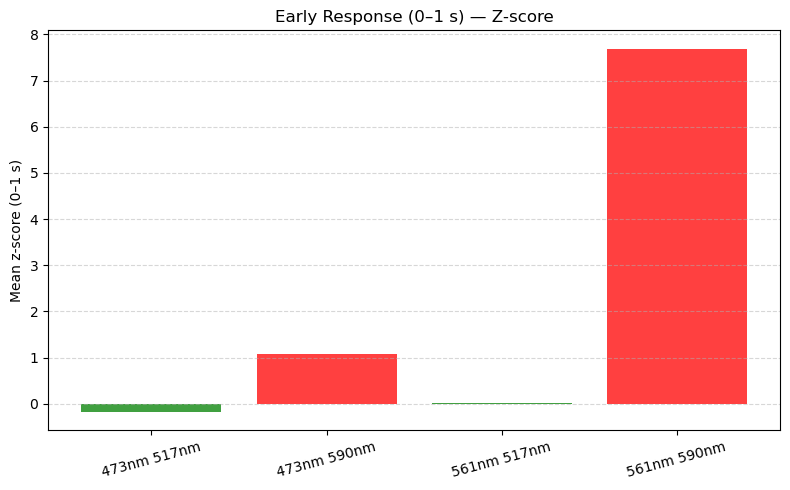

In [16]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SAMPLE_DIR = PROJECT_ROOT / "data" / "sample" / "jRGECO"

FILE_473 = SAMPLE_DIR / "Flna33_473nm_stimuli_python.mat"
FILE_561 = SAMPLE_DIR / "Flna33_561nm_stimuli_python.mat"

def load_stimuli_file(mat_path):
    if not mat_path.exists():
        raise FileNotFoundError(f"Sample dataset not found: {mat_path}")

    data = loadmat(mat_path)

    photo1 = data['photo1'].flatten()
    photo2 = data['photo2'].flatten()
    sol1times = data['sol1times'].flatten()
    downsamplingrate = int(data['downsamplingrate'][0][0])

    return photo1, photo2, sol1times, downsamplingrate

def compute_reward_aligned_zscore(photo1, photo2, sol1times, rate):
    pre, post = 2, 6
    zphoto1 = []
    zphoto2 = []

    for t in sol1times:
        idx = int(t * rate)
        start = idx - int(pre * rate)
        end   = idx + int(post * rate)

        if start < 0 or end >= len(photo1):
            continue

        # Use the -3 s to -2 s interval as the baseline window for z-score normalization
        base_start = idx - int(3 * rate)
        base_end   = idx - int(2 * rate)

        if base_start < 0:
            continue

        b1 = photo1[base_start:base_end]
        b2 = photo2[base_start:base_end]

        m1, s1 = np.mean(b1), np.std(b1)
        m2, s2 = np.mean(b2), np.std(b2)

        if s1 < 1e-6 or s2 < 1e-6:
            continue

        seg1 = photo1[start:end]
        seg2 = photo2[start:end]

        zseg1 = (seg1 - m1) / s1
        zseg2 = (seg2 - m2) / s2

        zphoto1.append(zseg1)
        zphoto2.append(zseg2)

    zphoto1 = np.array(zphoto1)
    zphoto2 = np.array(zphoto2)

    time_vec = np.linspace(-pre, post, zphoto1.shape[1])
    return zphoto1, zphoto2, time_vec

def compute_early_response(z1, z2, time_vec):
    idx0 = np.argmin(np.abs(time_vec - 0))
    idx1 = np.argmin(np.abs(time_vec - 0.3))

    r1 = z1[:, idx0:idx1].mean(axis=1)
    r2 = z2[:, idx0:idx1].mean(axis=1)

    return r1.mean(), r2.mean()

if __name__ == "__main__":

    print("\nSelect 473nm file")
    p1_A, p2_A, sol1_A, rate_A = load_stimuli_file(FILE_473)

    print("\nSelect 561nm file")
    p1_B, p2_B, sol1_B, rate_B = load_stimuli_file(FILE_561)

    z1_A, z2_A, t_A = compute_reward_aligned_zscore(p1_A, p2_A, sol1_A, rate_A)
    z1_B, z2_B, t_B = compute_reward_aligned_zscore(p1_B, p2_B, sol1_B, rate_B)

    r1_A, r2_A = compute_early_response(z1_A, z2_A, t_A)
    r1_B, r2_B = compute_early_response(z1_B, z2_B, t_B)

    labels = ['473nm 517nm', '473nm 590nm', '561nm 517nm', '561nm 590nm']
    values = [r1_A, r2_A, r1_B, r2_B]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, values, color=['green', 'red', 'green', 'red'], alpha=0.75)
    plt.ylabel("Mean z-score (0–1 s)")
    plt.title("Early Response (0–1 s) — Z-score")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=15)

    plt.tight_layout()
    plt.show()


## Asymmetric Contamination Pattern in Dual-Color Interpretation

The combined comparisons showed that simultaneous expression of GCaMP6f and jRGECO1a could not be assumed to be spectrally independent. For reliable dual-color recording, each sensor would ideally remain confined to its own measurement range. However, unlike jRGECO1a, GCaMP6f produced a measurable signal in the red detection range, indicating that contamination occurred primarily from the green sensor into the red channel.

This result showed that the main obstacle to reliable dual-color interpretation was not general overlap alone, but specifically the directionally biased extension of GCaMP6f into the red measurement range.


Select 473nm file (stimuli_python.mat)
Loaded: C:\Users\admin\project\data\sample\GCaMP\Flna11_473nm_stimuli_python.mat

Select 561nm file (stimuli_python.mat)
Loaded: C:\Users\admin\project\data\sample\GCaMP\Flna11_561nm_stimuli_python.mat
[DEBUG] trials=40, nT=18000, time range=(-3.000,6.000)
[DEBUG] trials=40, nT=18000, time range=(-3.000,6.000)

Trials (473nm 590nm): 40, mean=0.597
Trials (561nm 590nm): 40, mean=0.015

===== 590 contamination index summary =====
[473] n=40 mean=0.5965  bootstrap95%CI=(0.2097, 0.9908)
[561] n=40 mean=0.0150  bootstrap95%CI=(-0.2165, 0.2487)


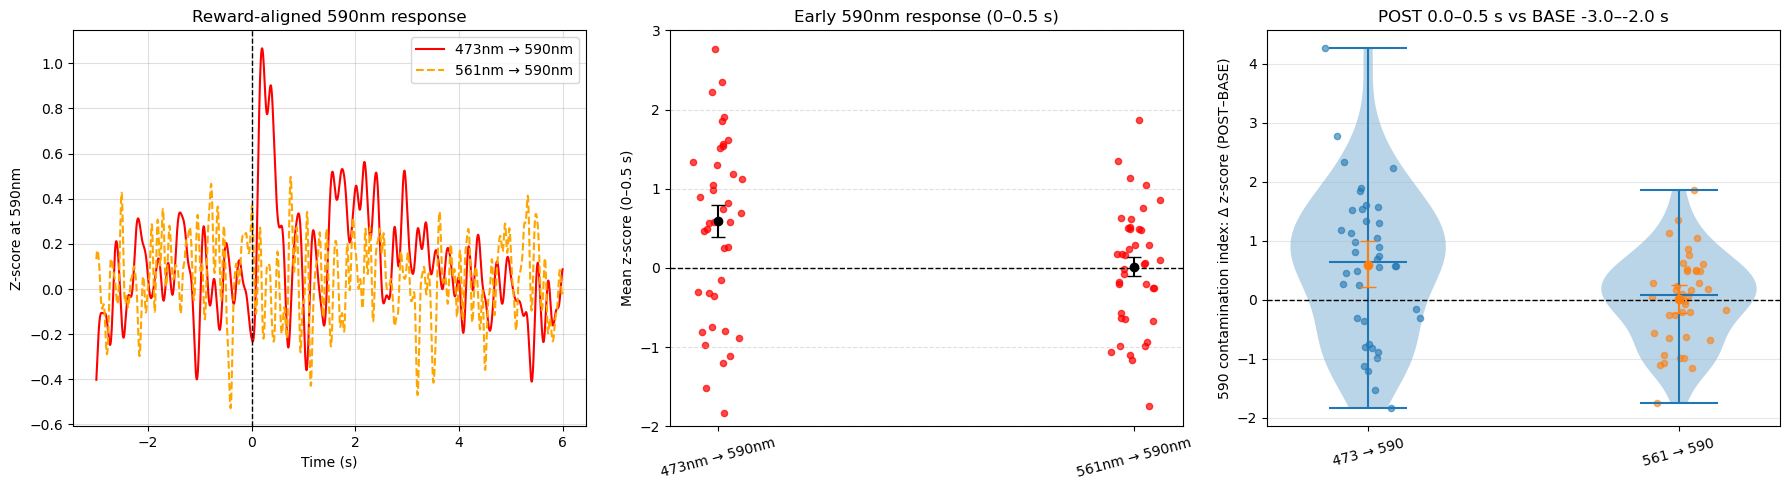

In [18]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SAMPLE_DIR = PROJECT_ROOT / "data" / "sample" / "GCaMP"

FILE_473 = SAMPLE_DIR / "Flna11_473nm_stimuli_python.mat"
FILE_561 = SAMPLE_DIR / "Flna11_561nm_stimuli_python.mat"

def load_stimuli_file(mat_path):
    if not mat_path.exists():
        raise FileNotFoundError(f"Sample dataset not found: {mat_path}")

    data = loadmat(mat_path)

    photo1 = data['photo1'].flatten()
    photo2 = data['photo2'].flatten()
    sol1times = data['sol1times'].flatten()
    downsamplingrate = int(data['downsamplingrate'][0][0])

    return photo1, photo2, sol1times, downsamplingrate

def compute_reward_aligned_zscore(photo1, photo2, sol1times, rate, pre=3, post=6):
    zphoto1 = []
    zphoto2 = []
    n = len(photo1)

    for t in sol1times:
        idx = int(t * rate)

        start = idx - int(pre * rate)
        end   = idx + int(post * rate)

        if start < 0 or end > n:
            continue

        # Baseline window for z-score normalization: -3 s to -2 s
        base_start = idx - int(3 * rate)
        base_end   = idx - int(2 * rate)

        if base_start < 0 or base_end > n:
            continue

        b1 = photo1[base_start:base_end]
        b2 = photo2[base_start:base_end]

        mean1, std1 = np.mean(b1), np.std(b1)
        mean2, std2 = np.mean(b2), np.std(b2)

        if std1 < 1e-6 or std2 < 1e-6:
            continue

        seg1 = photo1[start:end]
        seg2 = photo2[start:end]

        zseg1 = (seg1 - mean1) / std1
        zseg2 = (seg2 - mean2) / std2

        zphoto1.append(zseg1)
        zphoto2.append(zseg2)

    if len(zphoto1) == 0:
        raise ValueError("No valid trials for z-score calculation. Check sol1times or baseline window.")

    zphoto1 = np.array(zphoto1)
    zphoto2 = np.array(zphoto2)

    nT = zphoto1.shape[1]
    time_vec = (np.arange(nT) - int(pre * rate)) / rate

    print(f"[DEBUG] trials={zphoto1.shape[0]}, nT={nT}, time range=({time_vec[0]:.3f},{time_vec[-1]:.3f})")

    return zphoto1, zphoto2, time_vec

def per_trial_response(z_trials, time_vec, t_start=0.0, t_end=0.5):
    idx0 = np.argmin(np.abs(time_vec - t_start))
    idx1 = np.argmin(np.abs(time_vec - t_end))
    return z_trials[:, idx0:idx1].mean(axis=1)

def window_mean(z_trials, time_vec, t0, t1):
    mask = (time_vec >= t0) & (time_vec < t1)
    if not np.any(mask):
        raise ValueError(f"Window {t0}~{t1}s has no samples.")
    return z_trials[:, mask].mean(axis=1)


def bootstrap_mean_ci(x, nboot=5000, alpha=0.05, seed=0):
    x = np.asarray(x)
    rng = np.random.default_rng(seed)
    boots = rng.choice(x, size=(nboot, len(x)), replace=True).mean(axis=1)
    lo = np.quantile(boots, alpha/2)
    hi = np.quantile(boots, 1-alpha/2)
    return lo, hi

if __name__ == "__main__":

    print("\nSelect 473nm file (stimuli_python.mat)")
    p1_A, p2_A, sol1_A, rate_A = load_stimuli_file(FILE_473)

    print("\nSelect 561nm file (stimuli_python.mat)")
    p1_B, p2_B, sol1_B, rate_B = load_stimuli_file(FILE_561)

    z1_A, z2_A, t_A = compute_reward_aligned_zscore(p1_A, p2_A, sol1_A, rate_A)
    z1_B, z2_B, t_B = compute_reward_aligned_zscore(p1_B, p2_B, sol1_B, rate_B)

    mean_473_590 = z2_A.mean(axis=0)
    mean_561_590 = z2_B.mean(axis=0)

    resp_473_590 = per_trial_response(z2_A, t_A, 0, 0.5)
    resp_561_590 = per_trial_response(z2_B, t_B, 0, 0.5)

    print(f"\nTrials (473nm 590nm): {len(resp_473_590)}, mean={resp_473_590.mean():.3f}")
    print(f"Trials (561nm 590nm): {len(resp_561_590)}, mean={resp_561_590.mean():.3f}")

    post = (0.0, 0.5)
    base = (-3.0, -2.0)

    post_A = window_mean(z2_A, t_A, post[0], post[1])
    base_A = window_mean(z2_A, t_A, base[0], base[1])
    dA = post_A - base_A

    post_B = window_mean(z2_B, t_B, post[0], post[1])
    base_B = window_mean(z2_B, t_B, base[0], base[1])
    dB = post_B - base_B

    A_ci = bootstrap_mean_ci(dA, nboot=5000, seed=1)
    B_ci = bootstrap_mean_ci(dB, nboot=5000, seed=2)

    print("\n===== 590 contamination index summary =====")
    print(f"[473] n={len(dA)} mean={dA.mean():.4f}  bootstrap95%CI=({A_ci[0]:.4f}, {A_ci[1]:.4f})")
    print(f"[561] n={len(dB)} mean={dB.mean():.4f}  bootstrap95%CI=({B_ci[0]:.4f}, {B_ci[1]:.4f})")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.plot(t_A, mean_473_590, color='red', label='473nm → 590nm')
    ax.plot(t_B, mean_561_590, color='orange', label='561nm → 590nm', linestyle='--')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Z-score at 590nm")
    ax.set_title("Reward-aligned 590nm response")
    ax.legend()
    ax.grid(alpha=0.4)

    ax = axes[1]
    data = [resp_473_590, resp_561_590]
    labels = ["473nm → 590nm", "561nm → 590nm"]
    x_positions = [0, 1]

    for i, y in enumerate(data):
        x = np.random.normal(loc=x_positions[i], scale=0.03, size=len(y))
        ax.scatter(x, y, alpha=0.7, s=20, color='red')

    for i, y in enumerate(data):
        mean = y.mean()
        sem = y.std(ddof=1) / np.sqrt(len(y))
        ax.errorbar(
            x_positions[i],
            mean,
            yerr=sem,
            fmt='o',
            color='black',
            capsize=5,
            markersize=6,
            label='_nolegend_'
        )

    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel("Mean z-score (0–0.5 s)")
    ax.set_title("Early 590nm response (0–0.5 s)")
    ax.set_ylim(-2, 3)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    ax = axes[2]
    vdata = [dA, dB]
    vpos = [0, 1]
    vlabels = ["473 → 590", "561 → 590"]

    ax.violinplot(vdata, positions=vpos, showmedians=True, showmeans=False)

    for i, y in enumerate(vdata):
        x = np.random.normal(loc=vpos[i], scale=0.06, size=len(y))
        ax.scatter(x, y, s=20, alpha=0.6)

    means = [dA.mean(), dB.mean()]
    yerr_low  = [means[0] - A_ci[0], means[1] - B_ci[0]]
    yerr_high = [A_ci[1] - means[0], B_ci[1] - means[1]]
    ax.errorbar(vpos, means, yerr=[yerr_low, yerr_high], fmt='o', capsize=6)

    ax.axhline(0, linestyle='--', linewidth=1, color='black')
    ax.set_xticks(vpos)
    ax.set_xticklabels(vlabels, rotation=15)
    ax.set_ylabel("590 contamination index: Δ z-score (POST–BASE)")
    ax.set_title(f"POST {post[0]}–{post[1]} s vs BASE {base[0]}–{base[1]} s")
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()



Select 473nm file (stimuli_python.mat)
Loaded: C:\Users\admin\project\data\sample\jRGECO\Flna33_473nm_stimuli_python.mat

Select 561nm file (stimuli_python.mat)
Loaded: C:\Users\admin\project\data\sample\jRGECO\Flna33_561nm_stimuli_python.mat
[DEBUG] trials=50, nT=18000, time range=(-3.000,6.000)
[DEBUG] trials=50, nT=18000, time range=(-3.000,6.000)

Trials (473nm 517nm): 50, mean=-0.110
Trials (561nm 517nm): 50, mean=0.000

===== 517 index (POST–BASE) summary =====
[473] n=50 mean=-0.1102  bootstrap95%CI=(-0.3306, 0.1044)
[561] n=50 mean=0.0002  bootstrap95%CI=(-0.3099, 0.3043)


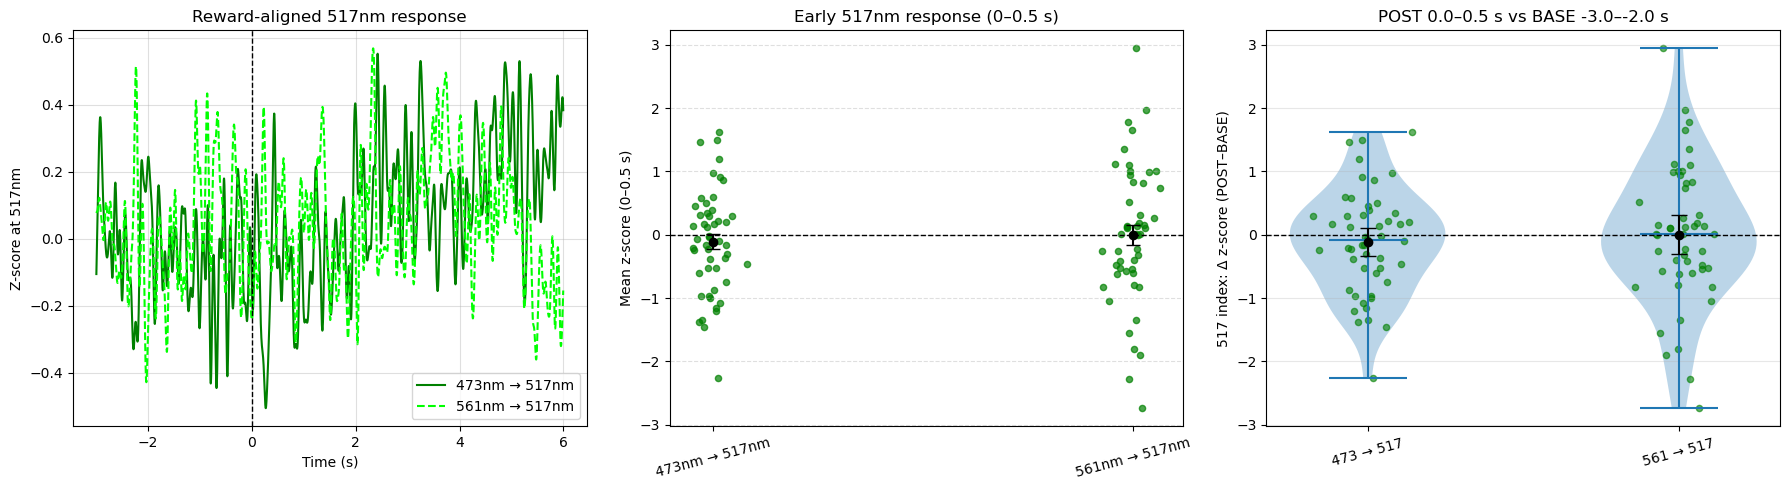

In [19]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SAMPLE_DIR = PROJECT_ROOT / "data" / "sample" / "jRGECO"

FILE_473 = SAMPLE_DIR / "Flna33_473nm_stimuli_python.mat"
FILE_561 = SAMPLE_DIR / "Flna33_561nm_stimuli_python.mat"

def load_stimuli_file(mat_path):
    if not mat_path.exists():
        raise FileNotFoundError(f"Sample dataset not found: {mat_path}")

    data = loadmat(mat_path)

    photo1 = data['photo1'].flatten()
    photo2 = data['photo2'].flatten()
    sol1times = data['sol1times'].flatten()
    downsamplingrate = int(data['downsamplingrate'][0][0])

    return photo1, photo2, sol1times, downsamplingrate

# Compute reward-aligned z-score traces for standardized comparison
def compute_reward_aligned_zscore(photo1, photo2, sol1times, rate, pre=3, post=6):
    zphoto1 = []
    zphoto2 = []
    n = len(photo1)

    for t in sol1times:
        idx = int(t * rate)

        start = idx - int(pre * rate)
        end   = idx + int(post * rate)

        if start < 0 or end > n:
            continue

        # Baseline window for z-score normalization: -3 s to -2 s
        base_start = idx - int(3 * rate)
        base_end   = idx - int(2 * rate)

        if base_start < 0 or base_end > n:
            continue

        b1 = photo1[base_start:base_end]
        b2 = photo2[base_start:base_end]

        mean1, std1 = np.mean(b1), np.std(b1)
        mean2, std2 = np.mean(b2), np.std(b2)

        if std1 < 1e-6 or std2 < 1e-6:
            continue

        seg1 = photo1[start:end]
        seg2 = photo2[start:end]

        zseg1 = (seg1 - mean1) / std1
        zseg2 = (seg2 - mean2) / std2

        zphoto1.append(zseg1)
        zphoto2.append(zseg2)

    if len(zphoto1) == 0:
        raise ValueError("No valid trials for z-score calculation. Check sol1times or baseline window.")

    zphoto1 = np.array(zphoto1)
    zphoto2 = np.array(zphoto2)

    nT = zphoto1.shape[1]
    time_vec = (np.arange(nT) - int(pre * rate)) / rate

    return zphoto1, zphoto2, time_vec

def per_trial_response(z_trials, time_vec, t_start=0.0, t_end=0.5):
    idx0 = np.argmin(np.abs(time_vec - t_start))
    idx1 = np.argmin(np.abs(time_vec - t_end))
    return z_trials[:, idx0:idx1].mean(axis=1)

def window_mean(z_trials, time_vec, t0, t1):
    mask = (time_vec >= t0) & (time_vec < t1)
    if not np.any(mask):
        raise ValueError(f"Window {t0}~{t1}s has no samples.")
    return z_trials[:, mask].mean(axis=1)

def bootstrap_mean_ci(x, nboot=5000, alpha=0.05, seed=0):
    x = np.asarray(x)
    rng = np.random.default_rng(seed)
    boots = rng.choice(x, size=(nboot, len(x)), replace=True).mean(axis=1)
    lo = np.quantile(boots, alpha/2)
    hi = np.quantile(boots, 1-alpha/2)
    return lo, hi

if __name__ == "__main__":

    print("\nSelect 473nm file (stimuli_python.mat)")
    p1_A, p2_A, sol1_A, rate_A = load_stimuli_file(FILE_473)

    print("\nSelect 561nm file (stimuli_python.mat)")
    p1_B, p2_B, sol1_B, rate_B = load_stimuli_file(FILE_561)

    z1_A, z2_A, t_A = compute_reward_aligned_zscore(p1_A, p2_A, sol1_A, rate_A)
    z1_B, z2_B, t_B = compute_reward_aligned_zscore(p1_B, p2_B, sol1_B, rate_B)

    mean_473_517 = z1_A.mean(axis=0)
    mean_561_517 = z1_B.mean(axis=0)

    resp_473_517 = per_trial_response(z1_A, t_A, 0, 0.5)
    resp_561_517 = per_trial_response(z1_B, t_B, 0, 0.5)

    print(f"\nTrials (473nm 517nm): {len(resp_473_517)}, mean={resp_473_517.mean():.3f}")
    print(f"Trials (561nm 517nm): {len(resp_561_517)}, mean={resp_561_517.mean():.3f}")

    post = (0.0, 0.5)
    base = (-3.0, -2.0)

    post_A = window_mean(z1_A, t_A, post[0], post[1])
    base_A = window_mean(z1_A, t_A, base[0], base[1])
    dA = post_A - base_A

    post_B = window_mean(z1_B, t_B, post[0], post[1])
    base_B = window_mean(z1_B, t_B, base[0], base[1])
    dB = post_B - base_B

    A_ci = bootstrap_mean_ci(dA, nboot=5000, seed=1)
    B_ci = bootstrap_mean_ci(dB, nboot=5000, seed=2)

    print("\n===== 517 index (POST–BASE) summary =====")
    print(f"[473] n={len(dA)} mean={dA.mean():.4f}  bootstrap95%CI=({A_ci[0]:.4f}, {A_ci[1]:.4f})")
    print(f"[561] n={len(dB)} mean={dB.mean():.4f}  bootstrap95%CI=({B_ci[0]:.4f}, {B_ci[1]:.4f})")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.plot(t_A, mean_473_517, color='green', label='473nm → 517nm')
    ax.plot(t_B, mean_561_517, color='lime', label='561nm → 517nm', linestyle='--')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Z-score at 517nm")
    ax.set_title("Reward-aligned 517nm response")
    ax.legend()
    ax.grid(alpha=0.4)

    ax = axes[1]
    data = [resp_473_517, resp_561_517]
    labels = ["473nm → 517nm", "561nm → 517nm"]
    x_positions = [0, 1]

    for i, y in enumerate(data):
        x = np.random.normal(loc=x_positions[i], scale=0.03, size=len(y))
        ax.scatter(x, y, alpha=0.7, s=20, color='green')

    for i, y in enumerate(data):
        mean = y.mean()
        sem = y.std(ddof=1) / np.sqrt(len(y))
        ax.errorbar(
            x_positions[i],
            mean,
            yerr=sem,
            fmt='o',
            color='black',
            capsize=5,
            markersize=6,
            label='_nolegend_'
        )

    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel("Mean z-score (0–0.5 s)")
    ax.set_title("Early 517nm response (0–0.5 s)")
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    ax = axes[2]
    vdata = [dA, dB]
    vpos = [0, 1]
    vlabels = ["473 → 517", "561 → 517"]

    ax.violinplot(vdata, positions=vpos, showmedians=True, showmeans=False)

    for i, y in enumerate(vdata):
        x = np.random.normal(loc=vpos[i], scale=0.06, size=len(y))
        ax.scatter(x, y, s=20, alpha=0.6, color='green')

    means = [dA.mean(), dB.mean()]
    yerr_low  = [means[0] - A_ci[0], means[1] - B_ci[0]]
    yerr_high = [A_ci[1] - means[0], B_ci[1] - means[1]]
    ax.errorbar(vpos, means, yerr=[yerr_low, yerr_high], fmt='o', capsize=6, color='black')

    ax.axhline(0, linestyle='--', linewidth=1, color='black')
    ax.set_xticks(vpos)
    ax.set_xticklabels(vlabels, rotation=15)
    ax.set_ylabel("517 index: Δ z-score (POST–BASE)")
    ax.set_title(f"POST {post[0]}–{post[1]} s vs BASE {base[0]}–{base[1]} s")
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


## Outcome

This stage established the key experimental evidence required for the next step of the project. The comparisons showed that signal contamination between the two sensors was not symmetric: GCaMP6f extended into the red measurement range, whereas jRGECO1a remained largely confined to its expected red-specific region.

As a result, the main obstacle to reliable dual-color recording was not general overlap alone, but specifically the extension of GCaMP6f-derived signal into the red measurement range.